# Esperimenti tesi

Il primo esperimento che voglio fare è fittare una serie di alberi con diverse profondità su dei dati sintetici $y \in \{1,-1\}$ e verificare se la differenza tra l'errore su un training set ($\hat R$) e l'errore su un test set ($R$) segue l'andamento previsto dal bound teorico
\begin{equation}
0 \le \mathbb{E}_D[R(\hat f_D)-\hat R(\hat f_D)] \le 2 \sqrt{\frac{\log \vert \mathcal{H}\vert}{2n}}
\end{equation}
cioè aumenta all'aumentare della profondità del mio albero in un modo controllato. 

N.B. parlo di profondità perché nel caso degli alberi, la cardinalità dell'insieme di ipotesi $\mathcal{H}$ è proporzionale alla profondità, in altre parole più profondo l'albero più comlpesso il modello che impariamo. 

### dati


Costruiamo un dataset sintetico di size $n$, secondo la legge 
\begin{gather}
x \sim \mathrm{Unif}(\text{supp}(0,10))\tag{2}\\
y \coloneqq \mathrm{sign}(f(x) + \varepsilon), \quad \varepsilon \sim \mathcal{N}(0,\sigma^2)\tag{3}
\end{gather}
for some $f: X \to Y$ convex and where $\text{supp}(0,10)$ is a discretization of the interval $[0,10]$. 


In [1]:
print('mare')

mare


In [45]:
# build dataset

import numpy as np

rng = np.random.default_rng(seed=4)  

def sample_x(data_size, supp_size, l=0.0, u=10.0, rng=rng):
    """sample n points from supp evenly spaced points on [l, u]"""
    support = np.linspace(l, u, supp_size)
    return rng.choice(support, size=data_size, replace=True)

def sample_y(x, f, sigma=1.0, rng=rng):
    """y = sign(f(x) + e), e ~ N(0, sigma)"""
    e = sigma * rng.standard_normal(size=len(x))
    return np.sign(f(x) + e)

def sample_y_bernoulli(x, f, p=0.8, rng=rng):
    """y = sign(f(x)) * b, b = +1 w.p. p, b = -1 w.p. 1-p"""
    b = rng.choice(np.array([1, -1]), size=len(x), p=[p, 1 - p])
    return np.sign(f(x)) * b

Notation:

- $N$ is the size of the support of the x
- $n$ is the number of training samples
- $n_\text{test}$ is the number of test samples

and we want $n << N << n_\text{test} \approx \infty$. 

### modelli e plot

we train **binary trees** with depths ranging from 1 to a multiple of the $\log_2 n$ threshold to see long term trends, using a **counting loss**. 

we compute the expected values of $R$ and $\hat R$ (and their difference) over the disorder of the data $D$ averaging over a number of training samples equal to ```max_iter```. 

we then do a number of plots to visualize to what extent empirical results confirm the theoretical bound $\text{(1)}$. 

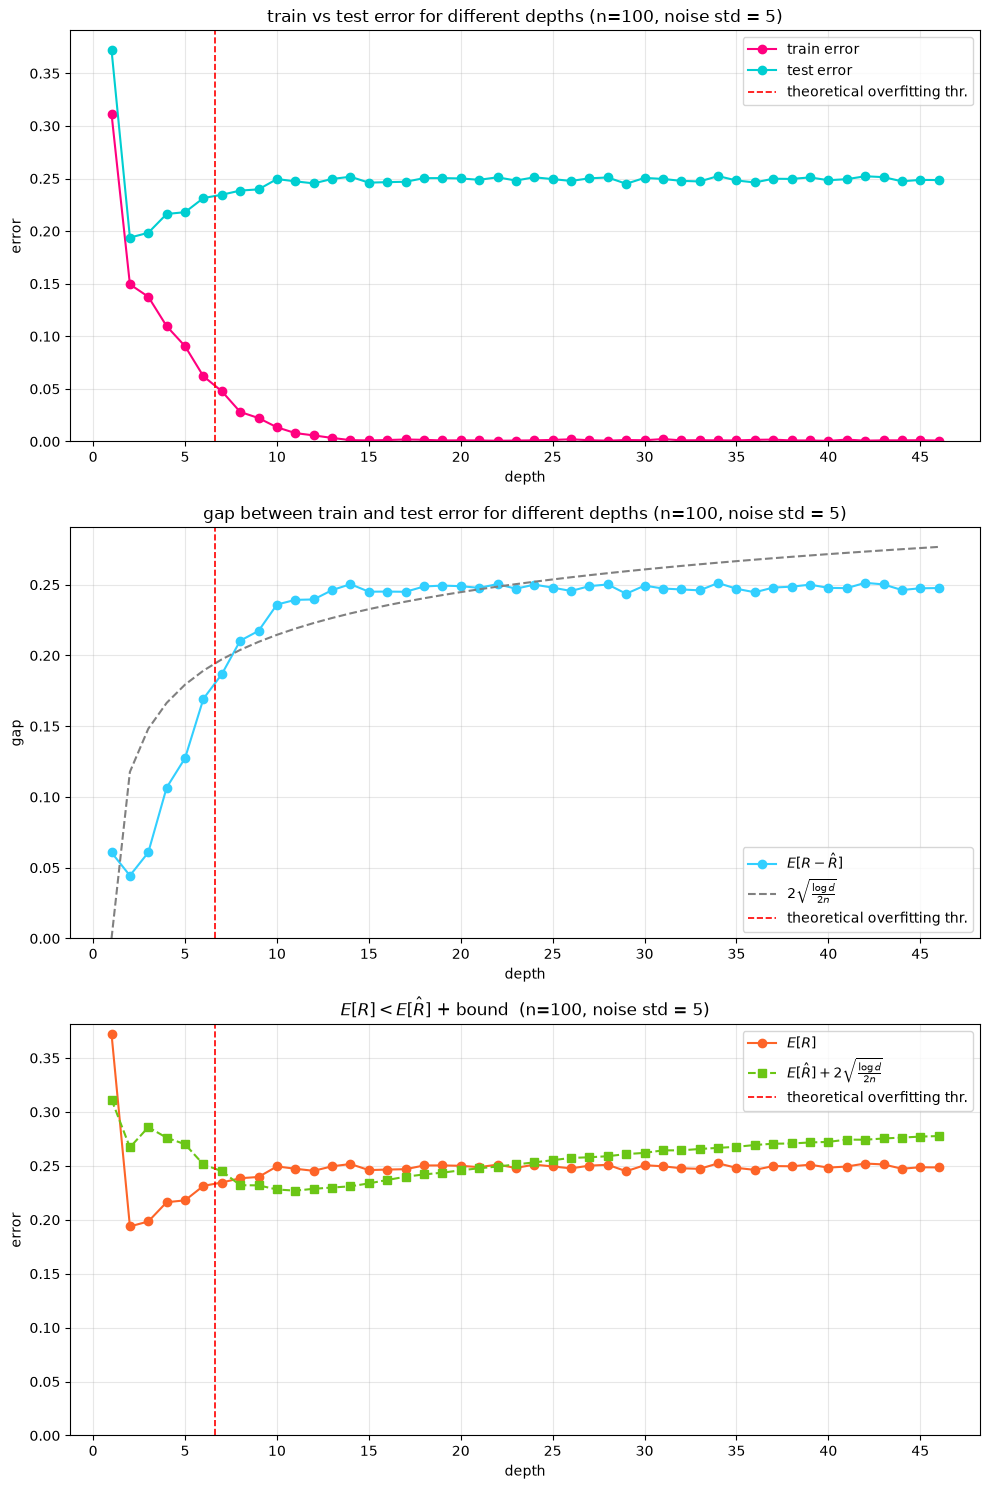

In [64]:
# generate hat R and R with empirical expecte dvalue (i.e. make a number max_iter of samples, compute hat R and R, and then average)

from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# PARAMETERS
max_iter = 100
N = 10_000
n = 100
n_test = 200_000
noise_std = 5
def centered_parabola(x):
    return (x-5)**2 - 6.25

# create test set
x_test = sample_x(n_test, N)
y_test = sample_y(x_test, centered_parabola, sigma=noise_std)

# DEPTHS
threshold = np.log2(n)  # interpolation threshold
threshold_int = int(np.floor(threshold))
# each integer from 1 to 4 times the threshold
depths = np.arange(1, int(np.floor(7 * threshold)) + 1)
depths_float = depths.astype(float)


# MAIN LOOP
E_hat_Rs = []  # E[hat R] per depth
E_Rs     = []  # E[R]     per depth
E_gaps   = []
for d in depths:
    hat_Rs = []
    Rs = []
    gaps = []
    for i in range(max_iter):
        # sample training set
        x = sample_x(n, N)
        y = sample_y(x, centered_parabola, sigma=noise_std)
        # fit tree
        clf = DecisionTreeClassifier(max_depth=int(d), random_state=42)
        clf.fit(x.reshape(-1, 1), y)
        # get errors
        train_err = 1 - clf.score(x.reshape(-1, 1), y)
        test_err  = 1 - clf.score(x_test.reshape(-1, 1), y_test)
        gap = test_err - train_err
        # running averages
        hat_Rs.append(train_err)
        Rs.append(test_err)
        gaps.append(gap)
        E_hat_R_running = np.cumsum(hat_Rs) / np.arange(1, len(hat_Rs) + 1)
        E_R_running     = np.cumsum(Rs)     / np.arange(1, len(Rs)     + 1)
        E_gap_running   = np.cumsum(gaps)   / np.arange(1, len(gaps)   + 1)
    # store expected value for each quantity for each depth
    E_hat_Rs.append(E_hat_R_running[-1])
    E_Rs.append(E_R_running[-1])
    E_gaps.append(E_gap_running[-1])

E_hat_Rs = np.array(E_hat_Rs)
E_Rs     = np.array(E_Rs)
E_gaps   = np.array(E_gaps)


# PLOTS
zero_train = next((d for d, e in zip(depths_float, E_hat_Rs) if e == 0), None)
bound = 2 * np.sqrt(np.log(depths_float) / (2 * n))

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 15))

#1 R and R hat
ax1.plot(depths_float, E_hat_Rs, color="#FF007F", marker="o", label="train error")
ax1.plot(depths_float, E_Rs,     color="#00CED1", marker="o", label="test error")
ax1.axvline(threshold, color="red", linestyle="--", linewidth=1.2, label="theoretical overfitting thr.")
if zero_train is not None:
    ax1.axvline(zero_train, color="blue", linestyle="--", linewidth=1.2, label="empirical overfitting thr.")
ax1.set_xlabel("depth")
ax1.set_ylabel("error")
ax1.set_ylim(bottom=0)
ax1.set_title(f"train vs test error for different depths (n={n}, noise std = {noise_std})")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(plt.MultipleLocator(5))

#2 gap and theoretical bound
ax2.plot(depths_float, E_gaps, color="#32CFFFFF", marker="o", label="$E [R-\hat R]$")
ax2.plot(depths_float, bound,  color="gray",      linestyle="--", label=r"$2\sqrt{\frac{\log d}{2n}}$")
ax2.axvline(threshold, color="red", linestyle="--", linewidth=1.2, label="theoretical overfitting thr.")
if zero_train is not None:
    ax2.axvline(zero_train, color="blue", linestyle="--", linewidth=1.2, label="empirical overfitting thr.")
ax2.set_xlabel("depth")
ax2.set_ylabel("gap")
ax2.set_ylim(bottom=0)
ax2.set_title(f"gap between train and test error for different depths (n={n}, noise std = {noise_std})")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_locator(plt.MultipleLocator(5))

#3 R \le R_hat + bound
RHS = E_hat_Rs + bound
ax3.plot(depths_float, E_Rs, color="#FD6428FF", marker="o", label="$E[R]$")
ax3.plot(depths_float, RHS,  color="#6BC615FF", linestyle="--", marker="s", label=r"$ E [\hat R] + 2\sqrt{\frac{\log d}{2n}}$")
ax3.axvline(threshold, color="red", linestyle="--", linewidth=1.2, label="theoretical overfitting thr.")
if zero_train is not None:
    ax3.axvline(zero_train, color="blue", linestyle="--", linewidth=1.2, label="empirical overfitting thr.")
ax3.set_xlabel("depth")
ax3.set_ylabel("error")
ax3.set_ylim(bottom=0)
ax3.set_title(f"$ E[R] < E[\hat R]$ + bound  (n={n}, noise std = {noise_std})")
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_locator(plt.MultipleLocator(5))

plt.tight_layout()
plt.show()


n.b. ho tolto la linea di overfitting empirico perche non ha tanto senso avendo ora la noise dei dati. non so dove metterla hehe. 

commento ai grafici: il bound teorico non è rispettato in una zona che sembra essere appena dopo l'overfitting 

In [65]:
# make everything function-based

def run_loop(x_test, y_test, n_train=50, sigma=1, N=10_000, max_iter=100,
              fun=centered_parabola, depths_list=depths):
    E_hat_Rs = []; E_Rs = []; E_gaps = []
    for d in depths_list:
        hat_Rs = []; Rs = []; gaps = []
        for i in range(max_iter):
            x = sample_x(n_train, N)
            y = sample_y(x, fun, sigma)
            clf = DecisionTreeClassifier(max_depth=int(d), random_state=42)
            clf.fit(x.reshape(-1, 1), y)
            train_err = 1 - clf.score(x.reshape(-1, 1), y)
            test_err  = 1 - clf.score(x_test.reshape(-1, 1), y_test)
            gap = test_err - train_err
            hat_Rs.append(train_err); Rs.append(test_err); gaps.append(gap)
            E_hat_R_running = np.cumsum(hat_Rs) / np.arange(1, len(hat_Rs) + 1)
            E_R_running     = np.cumsum(Rs)     / np.arange(1, len(Rs)     + 1)
            E_gap_running   = np.cumsum(gaps)   / np.arange(1, len(gaps)   + 1)
        E_hat_Rs.append(E_hat_R_running[-1])
        E_Rs.append(E_R_running[-1])
        E_gaps.append(E_gap_running[-1])
    return np.array(E_hat_Rs), np.array(E_Rs), np.array(E_gaps)


def plots(E_hat_Rs, E_Rs, E_gaps, n_train=50, sigma=1,
          one=False, two=False, three=False,
          model='trees', depths_list_float=depths_float,
          axes=None):

    if model == 'trees':
        threshold = np.log2(n_train)
        bound = 2 * np.sqrt(np.log(depths_list_float) / (2 * n_train))

    n_plots = sum([one, two, three])
    if n_plots == 0:
        return
    if axes is None:
        fig, axs = plt.subplots(n_plots, 1, figsize=(10, 5 * n_plots))
        if n_plots == 1:
            axs = [axs]
    else:
        axs = axes
    ax_iter = iter(axs)

    if one:
        ax = next(ax_iter)
        zero_train = next((d for d, e in zip(depths_list_float, E_hat_Rs) if e == 0), None)
        ax.plot(depths_list_float, E_hat_Rs, color='#FF007F', marker='o', label=r'$E[\hat R]$')
        ax.plot(depths_list_float, E_Rs,     color='#00CED1', marker='o', label=r'$E[R]$')
        ax.axvline(threshold, color='red',  linestyle='--', linewidth=1.2, label='theoretical overfitting th.')
        # if zero_train is not None:
        #     ax.axvline(zero_train, color='blue', linestyle='--', linewidth=1.2, label='empirical overfitting th.')
        ax.set_ylim(bottom=0)
        ax.set_title(f'train vs test error for different depths (n={n_train}, noise std = {sigma})')
        ax.set_xlabel('depth'); ax.set_ylabel('error')
        ax.legend(); ax.grid(True, alpha=0.3)

    if two:
        ax = next(ax_iter)
        zero_train = next((d for d, e in zip(depths_list_float, E_hat_Rs) if e == 0), None)
        ax.plot(depths_list_float, E_gaps, color='#32CFFFFF', marker='o', label=r'$E[R - \hat R]$')
        ax.plot(depths_list_float, bound,  color='gray', linestyle='--', label=r'$2\sqrt{\frac{\log d}{2n}}$')
        ax.axvline(threshold, color='red',  linestyle='--', linewidth=1.2, label='theoretical overfitting th.')
        # if zero_train is not None:
        #     ax.axvline(zero_train, color='blue', linestyle='--', linewidth=1.2, label='empirical overfitting th.')
        ax.set_ylim(bottom=0)
        ax.set_title(f'gap between train and test error for different depths (n={n_train}, noise std = {sigma})')
        ax.set_xlabel('depth'); ax.set_ylabel('gap')
        ax.legend(); ax.grid(True, alpha=0.3)

    if three:
        ax = next(ax_iter)
        zero_train = next((d for d, e in zip(depths_list_float, E_hat_Rs) if e == 0), None)
        RHS = E_hat_Rs + bound
        ax.plot(depths_list_float, E_Rs,  color='#FD6428FF', marker='o', label=r'$E[R]$')
        ax.plot(depths_list_float, RHS,   color='#6BC615FF', linestyle='--', marker='s', label=r'$E[\hat R] + 2\sqrt{\frac{\log d}{2n}}$')
        ax.axvline(threshold, color='red',  linestyle='--', linewidth=1.2, label='theoretical overfitting th.')
        # if zero_train is not None:
        #     ax.axvline(zero_train, color='blue', linestyle='--', linewidth=1.2, label='empirical overfitting th.')
        ax.set_ylim(bottom=0)
        ax.set_title(f'$E[R] \leq E[\hat R]$ + bound  (n={n_train}, noise std = {sigma})')
        ax.set_xlabel('depth'); ax.set_ylabel('error')
        ax.legend(); ax.grid(True, alpha=0.3)

    if axes is None:
        plt.tight_layout()
        plt.show()


### try with different hyperpars (n_train, noise_std)

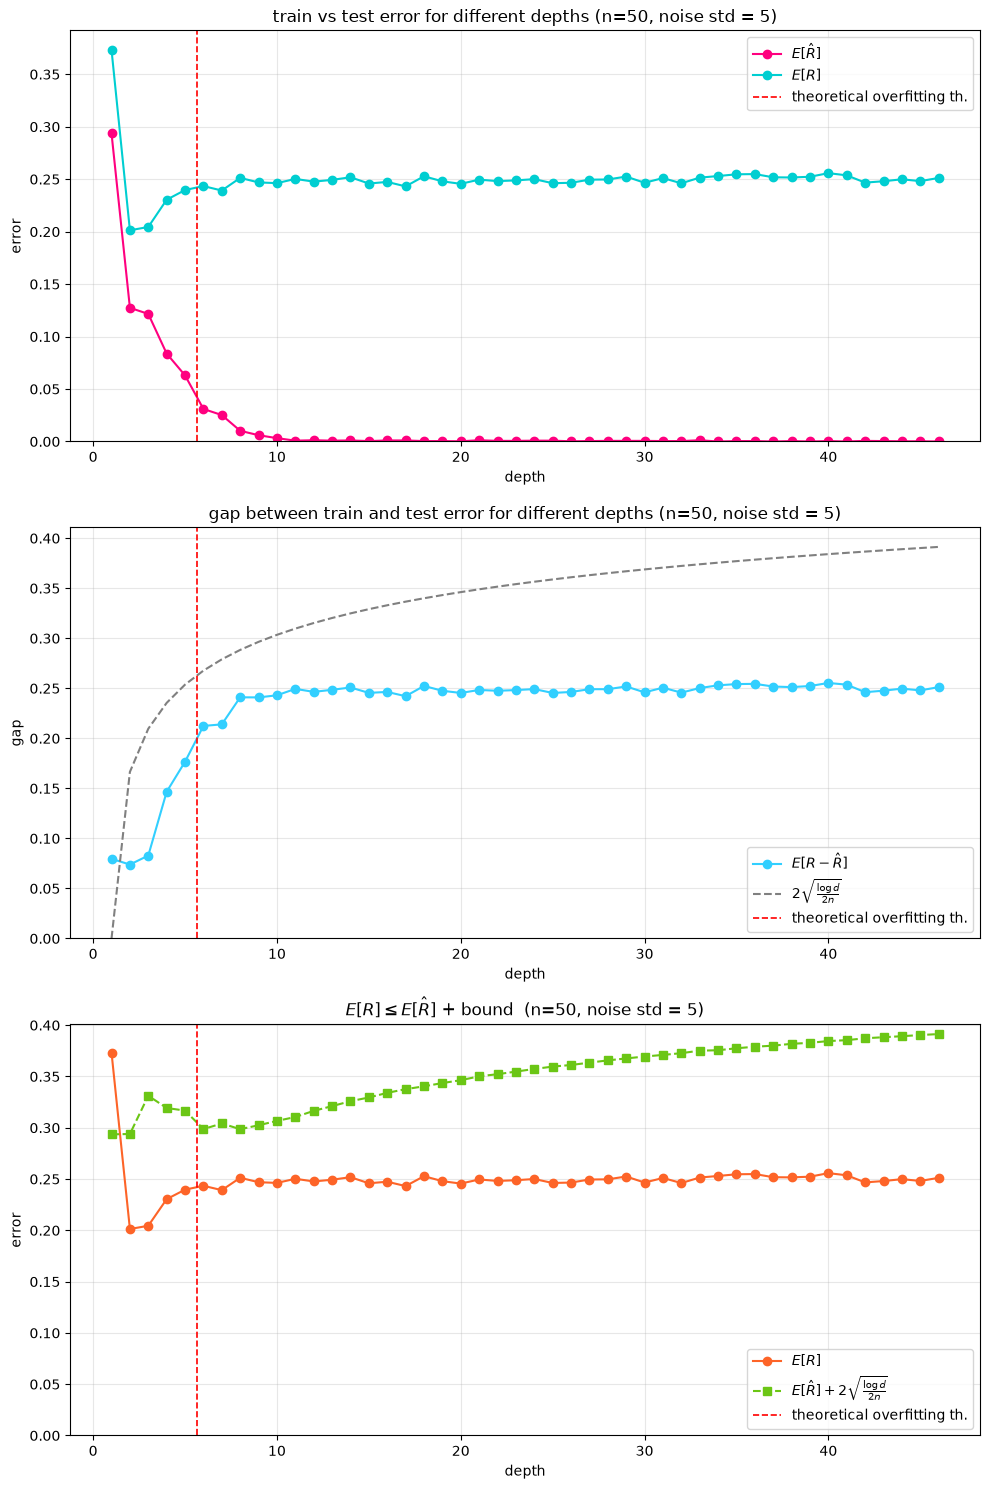

In [66]:

# PARAMETERS
max_iter = 100
N = 10_000
n_test = 200_000
def centered_parabola(x):
    return (x-5)**2 - 6.25

# DEPTHS
threshold = np.log2(n)  # interpolation threshold
threshold_int = int(np.floor(threshold))
# each integer from 1 to 4 times the threshold
depths = np.arange(1, int(np.floor(7 * threshold)) + 1)
depths_float = depths.astype(float)

# NEW PARS
n = 50
noise_std = 5

x_test = sample_x(200_000, 10_000)
y_test = sample_y(x = x_test, f = centered_parabola, sigma = 5)

hat_Rs, Rs, gaps = run_loop(x_test, y_test, n_train = n, sigma = 5)
plots(hat_Rs, Rs, gaps, n_train = n, sigma = 5, one = True, two= True,three = True)

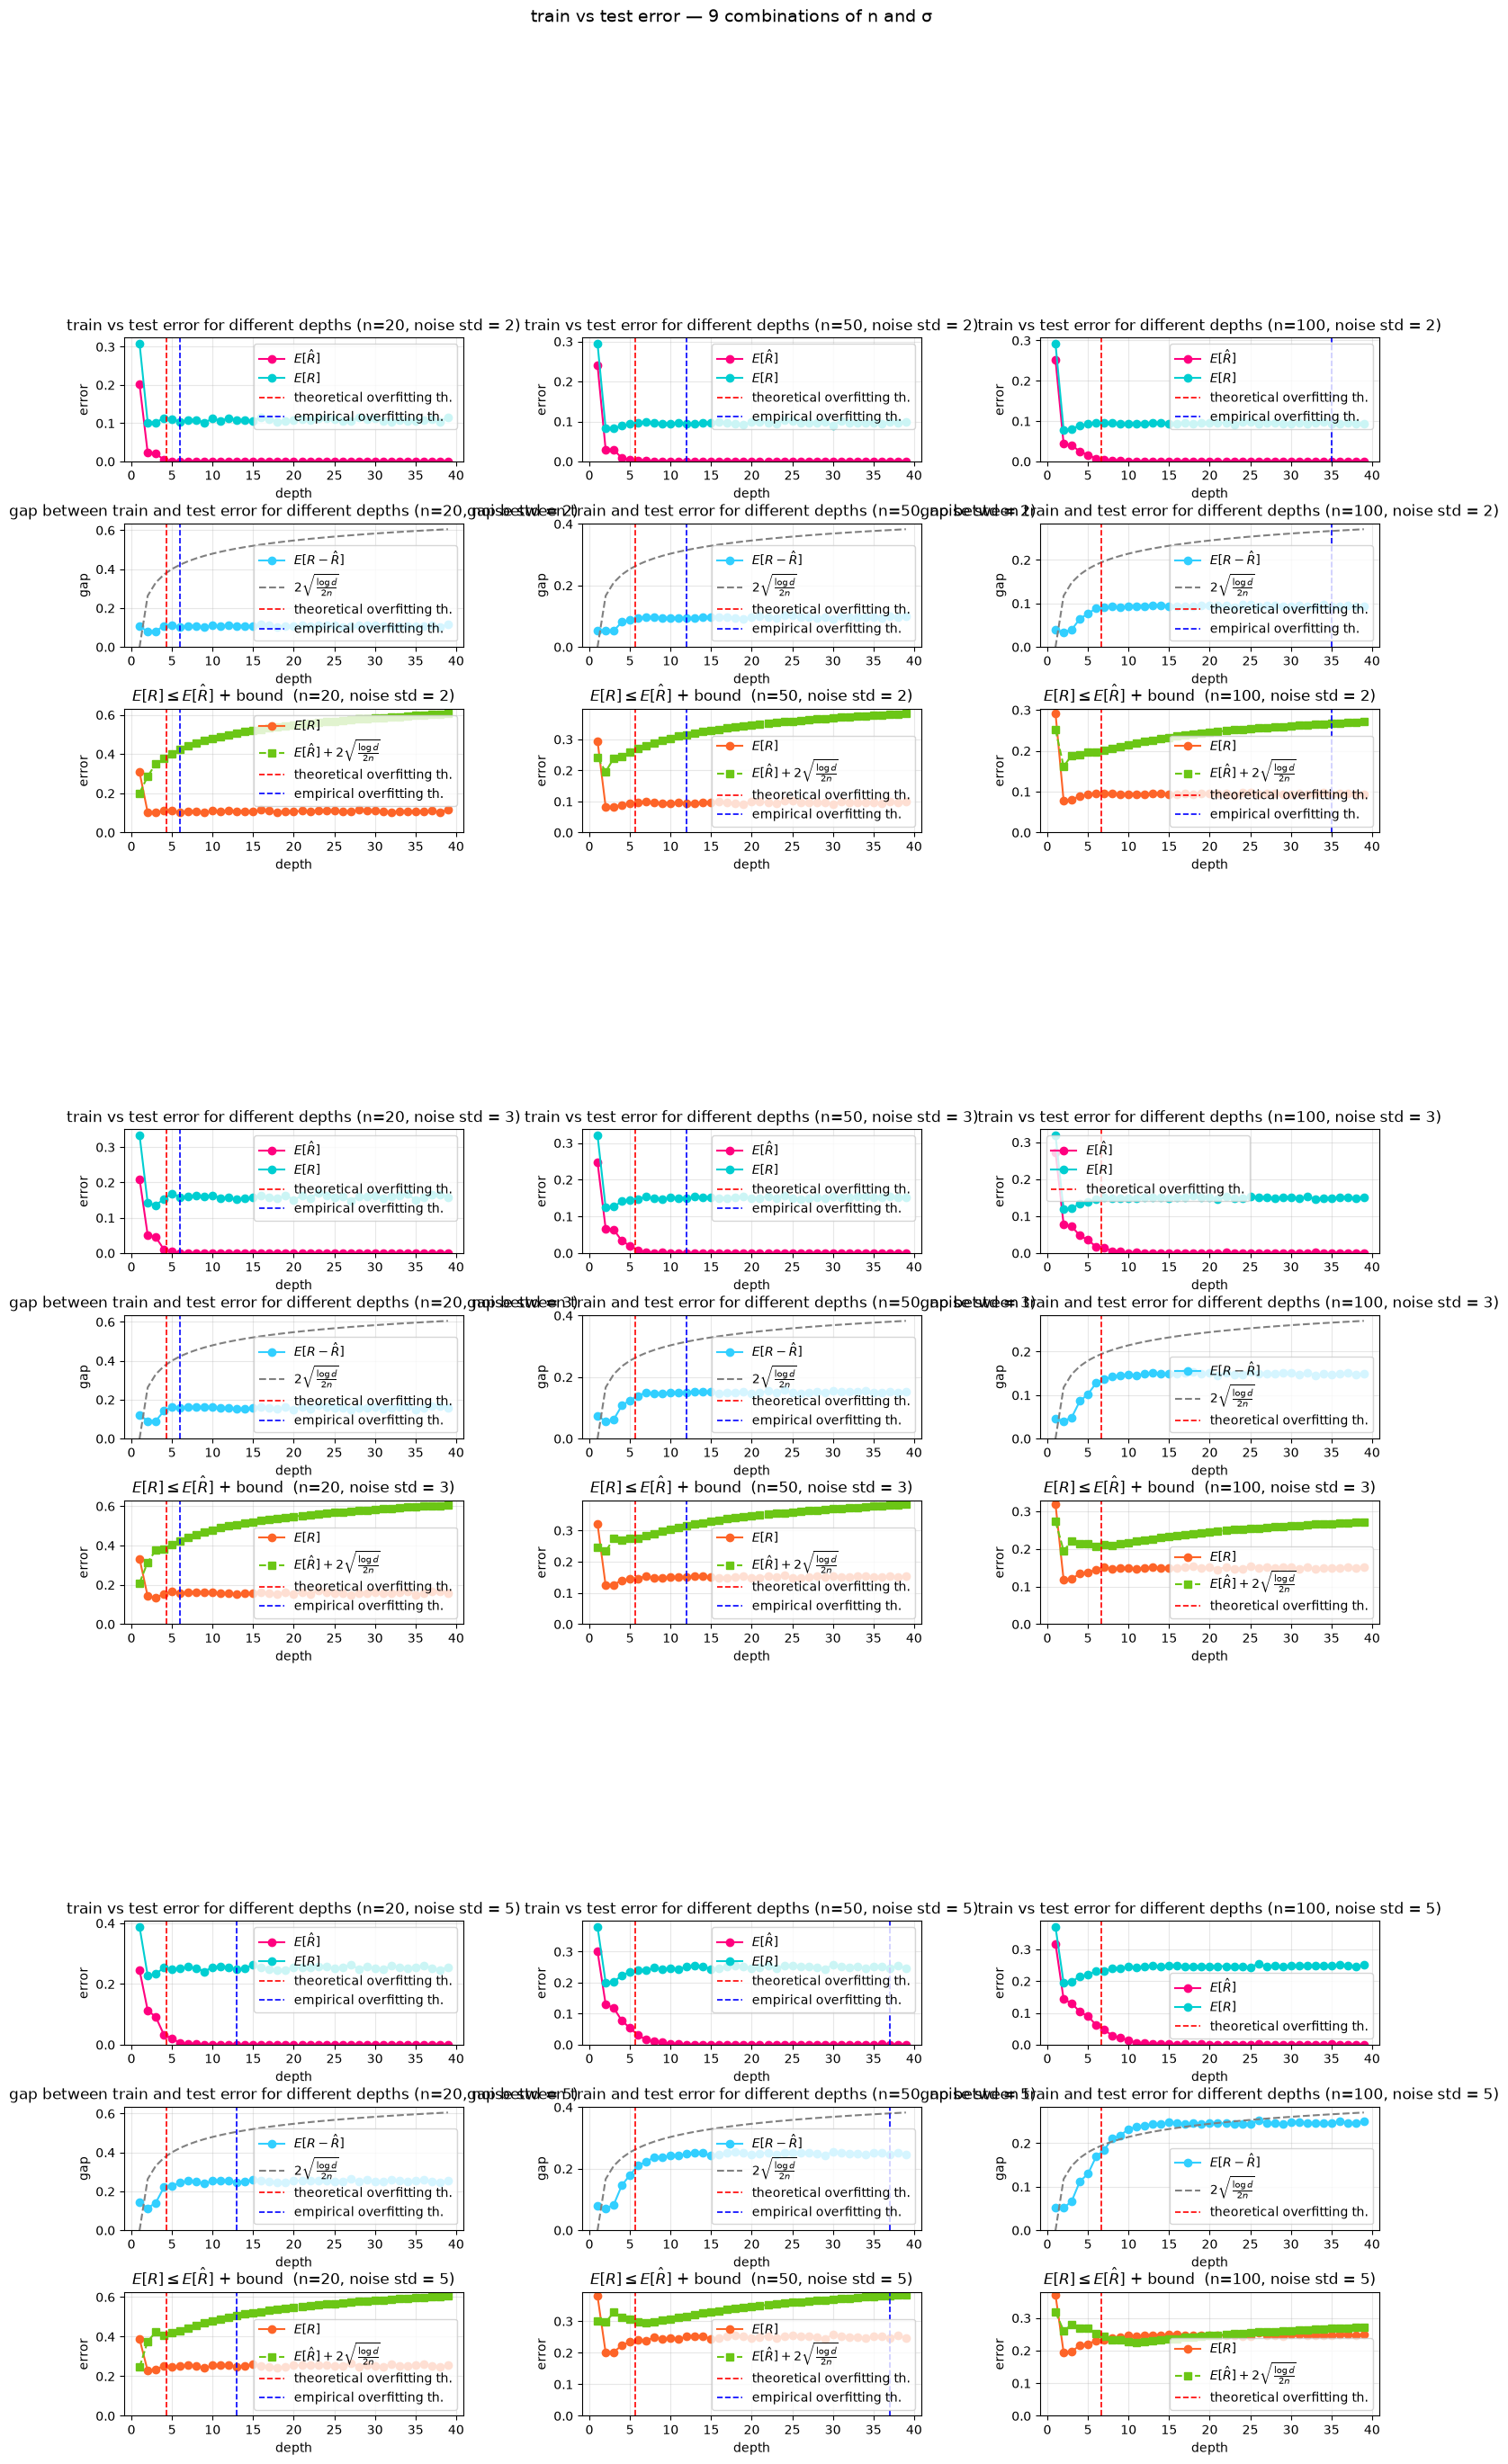

In [62]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

n_values   = [20, 50, 100]
std_values = [2, 3, 5]

fig = plt.figure(figsize=(18, 30))
outer_gs = GridSpec(3, 3, figure=fig, hspace=0.6, wspace=0.35)

for row, std in enumerate(std_values):
    x_test_loop = sample_x(200_000, 10_000)
    y_test_loop = sample_y(x_test_loop, centered_parabola, sigma=std)
    for col, n_val in enumerate(n_values):
        E_hat_Rs, E_Rs, E_gaps = run_loop(x_test_loop, y_test_loop, n_train=n_val, sigma=std)
        inner_gs = GridSpecFromSubplotSpec(3, 1, subplot_spec=outer_gs[row, col], hspace=0.5)
        axs = [fig.add_subplot(inner_gs[i]) for i in range(3)]
        plots(E_hat_Rs, E_Rs, E_gaps, n_train=n_val, sigma=std, one=True, two=True, three=True, axes=axs)

plt.suptitle('train vs test error — 9 combinations of n and σ', fontsize=14, y=1.002)
plt.show()
